In [1]:
# ── Task 1: Create & Justify Engineered Features ──

import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

# ── Load data (same as Day 1) ──
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
columns = ['age','workclass','fnlwgt','education','education_num','marital_status',
           'occupation','relationship','race','sex','capital_gain','capital_loss',
           'hours_per_week','native_country','income']
df = pd.read_csv(url, names=columns, na_values=' ?', skipinitialspace=True)
df.dropna(inplace=True)

# ── Same train/test split as Day 1 (stratified, random_state=42) ──
X = df.drop('income', axis=1)
y = (df['income'] == '>50K').astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Positive rate: {y_train.mean():.4f} (train), {y_test.mean():.4f} (test)')

# ── Create 7 Engineered Features ──

def engineer_features(df):
    """Create engineered features from raw columns. Uses only current-row data (no leakage)."""
    out = pd.DataFrame(index=df.index)

    # 1. has_capital_gain: binary flag
    #    Most people have capital_gain=0. The gap between 0 and any gain is what matters.
    out['has_capital_gain'] = (df['capital_gain'] > 0).astype(int)

    # 2. log_capital_gain: log(1 + capital_gain)
    #    Capital gain is wildly skewed (0 to 99999). Log compresses the range.
    out['log_capital_gain'] = np.log1p(df['capital_gain'])

    # 3. has_capital_loss: binary flag
    #    Same logic as gain — presence/absence matters more than exact value.
    out['has_capital_loss'] = (df['capital_loss'] > 0).astype(int)

    # 4. age_group: life-cycle bins
    #    Income follows a life cycle (low young → peaks mid-career → drops after retirement).
    out['age_group'] = pd.cut(
        df['age'],
        bins=[0, 24, 39, 54, 64, 100],
        labels=['<25', '25-39', '40-54', '55-64', '65+']
    )

    # 5. hours_category: work intensity bins
    #    Part-time vs full-time vs overtime → different income brackets.
    out['hours_category'] = pd.cut(
        df['hours_per_week'],
        bins=[0, 19, 39, 49, 100],
        labels=['<20', '20-39', '40-49', '50+']
    )

    # 6. higher_ed: binary flag (Bachelors or above)
    #    Clear threshold: college degree vs no degree.
    out['higher_ed'] = (df['education_num'] >= 14).astype(int)

    # 7. edu_hours_interaction: education_num × hours_per_week
    #    Combination: highly educated + long hours = highest earners.
    out['edu_hours_interaction'] = df['education_num'] * df['hours_per_week']

    return out

# ── Apply to train and test ──
eng_train = engineer_features(X_train)
eng_test = engineer_features(X_test)

print('\nEngineered features created:')
print(eng_train.columns.tolist())
print(f'Shape: {eng_train.shape}')
display(eng_train.head())

# ── Compute Mutual Information scores ──
# MI measures: how much does knowing this feature reduce uncertainty about income?
# MI = 0 → feature is useless. Higher = more informative.
# Need numeric-only input for MI (age_group and hours_category are categorical)
eng_train_numeric = pd.get_dummies(eng_train, drop_first=True)

mi_scores = mutual_info_classif(eng_train_numeric, y_train, random_state=42)

# Build feature dictionary
feature_dict = pd.DataFrame({
    'Feature': eng_train_numeric.columns,
    'MI_Score': np.round(mi_scores, 4)
}).sort_values('MI_Score', ascending=False).reset_index(drop=True)

print('\nFeature Dictionary — Mutual Information Scores:')
print('(Higher MI = more informative about income >50K)\n')
display(feature_dict)
print(f'\nBest feature: {feature_dict.iloc[0]["Feature"]} (MI={feature_dict.iloc[0]["MI_Score"]})')

Train: (26048, 14), Test: (6513, 14)
Positive rate: 0.2408 (train), 0.2407 (test)

Engineered features created:
['has_capital_gain', 'log_capital_gain', 'has_capital_loss', 'age_group', 'hours_category', 'higher_ed', 'edu_hours_interaction']
Shape: (26048, 7)


,has_capital_gain,log_capital_gain,has_capital_loss,age_group,hours_category,higher_ed,edu_hours_interaction
15738,0,0.000000,0,25-39,40-49,0,585
27985,0,0.000000,0,40-54,40-49,1,630
30673,0,0.000000,0,<25,20-39,0,252
9505,1,8.832004,0,40-54,40-49,0,400
26417,0,0.000000,0,<25,40-49,0,520



Feature Dictionary — Mutual Information Scores:
(Higher MI = more informative about income >50K)



,Feature,MI_Score
0,log_capital_gain,0.0843
1,edu_hours_interaction,0.0829
2,higher_ed,0.0317
3,has_capital_gain,0.0260
4,age_group_40-54,0.0253
5,hours_category_50+,0.0230
6,hours_category_20-39,0.0168
7,has_capital_loss,0.0102
8,age_group_25-39,0.0036
9,age_group_55-64,0.0025



Best feature: log_capital_gain (MI=0.0843)


In [5]:
# ── Task 2: Rebuild Pipeline with Engineered Features ──

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def engineer_features(df):
    """Create engineered features from raw columns. Returns original + new columns."""
    out = df.copy() 
    # 1. has_capital_gain: binary flag
    out['has_capital_gain'] = (df['capital_gain'] > 0).astype(int)
    # 2. log_capital_gain: log(1 + capital_gain)
    out['log_capital_gain'] = np.log1p(df['capital_gain'])
    # 3. has_capital_loss: binary flag
    out['has_capital_loss'] = (df['capital_loss'] > 0).astype(int)
    # 4. age_group: life-cycle bins
    out['age_group'] = pd.cut(df['age'], bins=[0,24,39,54,64,100], labels=['<25','25-39','40-54','55-64','65+'])
    # 5. hours_category: work intensity bins
    out['hours_category'] = pd.cut(df['hours_per_week'], bins=[0,19,39,49,100], labels=['<20','20-39','40-49','50+'])
    # 6. higher_ed: binary flag
    out['higher_ed'] = (df['education_num'] >= 14).astype(int)
    # 7. edu_hours_interaction: education_num × hours_per_week
    out['edu_hours_interaction'] = df['education_num'] * df['hours_per_week']
    return out

# ── Verify the fix ──
check = engineer_features(X_train)
print(f'Output columns: {check.shape[1]} (should be 21 = 14 original + 7 engineered)')
print(f'Columns: {check.columns.tolist()}')

# ── Define which columns are numeric vs categorical AFTER engineering ──
numeric_cols = [
    'age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
    'hours_per_week',
    'has_capital_gain', 'log_capital_gain', 'has_capital_loss',
    'higher_ed', 'edu_hours_interaction'
]

categorical_cols = [
    'workclass', 'education', 'marital_status', 'occupation',
    'relationship', 'race', 'sex', 'native_country',
    'age_group', 'hours_category'
]

# ── Build numeric sub-pipeline ──
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ── Build categorical sub-pipeline ──
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ── Combine into ColumnTransformer ──
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='drop'
)

# ── Wrap engineer_features in FunctionTransformer ──
engineer = FunctionTransformer(engineer_features)

# ── Build full pipeline (engineer → preprocess → model) ──
full_pipeline = Pipeline([
    ('engineer', engineer),
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        solver='liblinear',
        random_state=42,
        max_iter=1000
    ))
])

# ── Fit on training data only ──
full_pipeline.fit(X_train, y_train)

# ── Evaluate on test data ──
y_pred = full_pipeline.predict(X_test)
y_proba = full_pipeline.predict_proba(X_test)[:, 1]

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print('\nFull Pipeline (Engineer + Preprocess + LR) — Test Set Results:')
print(f'  Precision:  {precision:.4f}')
print(f'  Recall:     {recall:.4f}')
print(f'  F1:         {f1:.4f}')
print(f'  ROC AUC:    {roc_auc:.4f}')

# ── Check feature count ──
feature_names = full_pipeline.named_steps['preprocessor'].get_feature_names_out()
print(f'\nTotal features after preprocessing: {len(feature_names)}')
print(f'Original features: 14 → Engineered: 21 → After one-hot: {len(feature_names)}')

Output columns: 21 (should be 21 = 14 original + 7 engineered)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'has_capital_gain', 'log_capital_gain', 'has_capital_loss', 'age_group', 'hours_category', 'higher_ed', 'edu_hours_interaction']

Full Pipeline (Engineer + Preprocess + LR) — Test Set Results:
  Precision:  0.7528
  Recall:     0.6352
  F1:         0.6890
  ROC AUC:    0.9181

Total features after preprocessing: 122
Original features: 14 → Engineered: 21 → After one-hot: 122


Training: Logistic Regression...
  Done.
     precision: 0.7455 ± 0.0083
        recall: 0.6184 ± 0.0108
            f1: 0.6760 ± 0.0093
       roc_auc: 0.9130 ± 0.0045

Training: Random Forest...
  Done.
     precision: 0.7274 ± 0.0091
        recall: 0.6168 ± 0.0072
            f1: 0.6675 ± 0.0046
       roc_auc: 0.9021 ± 0.0043

Training: HistGradientBoosting...
  Done.
     precision: 0.7758 ± 0.0073
        recall: 0.6526 ± 0.0102
            f1: 0.7089 ± 0.0078
       roc_auc: 0.9255 ± 0.0025

Cross-Validation Summary:


,Model,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.7455,0.0083,0.6184,0.0108,0.6760,0.0093,0.9130,0.0045
1,Random Forest,0.7274,0.0091,0.6168,0.0072,0.6675,0.0046,0.9021,0.0043
2,HistGradientBoosting,0.7758,0.0073,0.6526,0.0102,0.7089,0.0078,0.9255,0.0025


C:\Users\muham\AppData\Local\Temp\ipykernel_6972\3417618819.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[n[:12] for n in results.keys()])
C:\Users\muham\AppData\Local\Temp\ipykernel_6972\3417618819.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[n[:12] for n in results.keys()])
C:\Users\muham\AppData\Local\Temp\ipykernel_6972\3417618819.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[n[:12] for n in results.keys()])
C:\Users\muham\AppData\Local\Temp\ipykernel_6972\3417618819.py:71: MatplotlibDeprecationWarning: The 'labels' pa

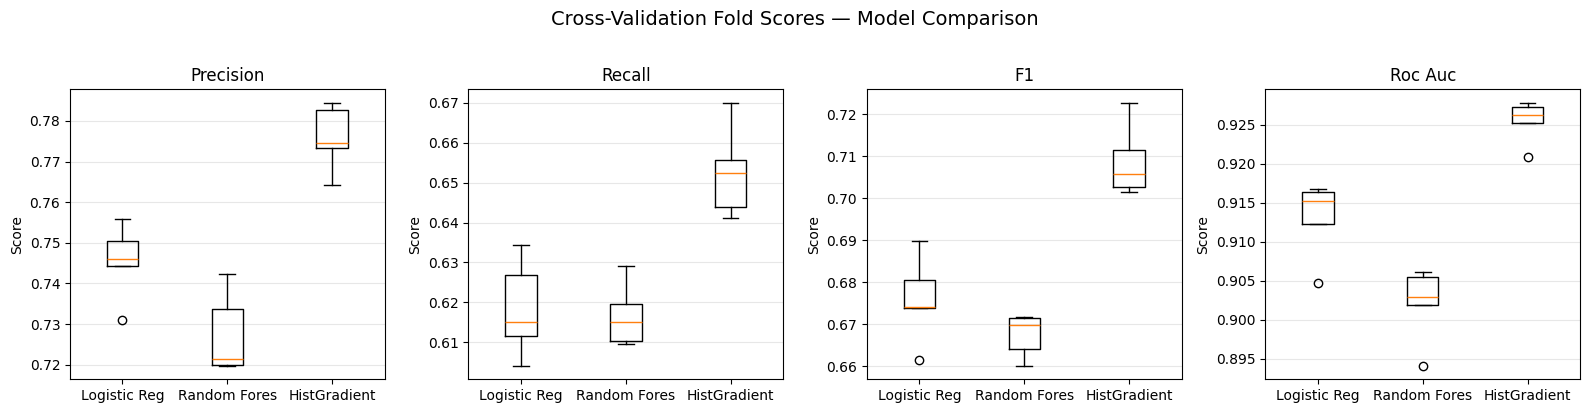


Raw fold scores (Precision):
  Logistic Regression: ['0.7310', '0.7559', '0.7459', '0.7443', '0.7505']
  Random Forest: ['0.7197', '0.7422', '0.7215', '0.7199', '0.7337']
  HistGradientBoosting: ['0.7732', '0.7845', '0.7642', '0.7828', '0.7746']


In [6]:
# ── Task 3: Cross-Validated Model Comparison (5-Fold Stratified) ──

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Define CV strategy ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Define three pipelines (same engineer + preprocessor, different classifier) ──
pipelines = {
    'Logistic Regression': Pipeline([
        ('engineer', FunctionTransformer(engineer_features)),
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(solver='liblinear', random_state=42, max_iter=1000))
    ]),
    'Random Forest': Pipeline([
        ('engineer', FunctionTransformer(engineer_features)),
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    'HistGradientBoosting': Pipeline([
        ('engineer', FunctionTransformer(engineer_features)),
        ('preprocessor', preprocessor),
        ('classifier', HistGradientBoostingClassifier(random_state=42))
    ])
}

# ── Run cross-validation for each model ──
scoring = ['precision', 'recall', 'f1', 'roc_auc']
results = {}

for name, pipeline in pipelines.items():
    print(f'Training: {name}...')
    cv_results = cross_validate(
        pipeline, X_train, y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    results[name] = cv_results
    print(f'  Done.')
    for metric in scoring:
        scores = cv_results[f'test_{metric}']
        print(f'  {metric:>12s}: {scores.mean():.4f} ± {scores.std():.4f}')
    print()

# ── Build comparison table ──
summary = []
for name in results:
    row = {'Model': name}
    for metric in scoring:
        scores = results[name][f'test_{metric}']
        row[f'{metric}_mean'] = scores.mean()
        row[f'{metric}_std'] = scores.std()
    summary.append(row)

summary_df = pd.DataFrame(summary)
print('Cross-Validation Summary:')
display(summary_df.round(4))

# ── Boxplot visualization ──
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, metric in enumerate(scoring):
    ax = axes[idx]
    data = [results[name][f'test_{metric}'] for name in results]
    ax.boxplot(data, labels=[n[:12] for n in results.keys()])
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cross-Validation Fold Scores — Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── Print raw fold scores for inspection ──
print('\nRaw fold scores (Precision):')
for name in results:
    scores = results[name]['test_precision']
    print(f'  {name}: {[f"{s:.4f}" for s in scores]}')

In [15]:
# ── Task 4: Statistical Comparison & Feature Importance (FAST) ──

from scipy.stats import wilcoxon
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ══════════════════════════════════════════════════
# PART A: Statistical Test (Wilcoxon) between HGB and LR on Precision
# ══════════════════════════════════════════════════

lr_precision = results['Logistic Regression']['test_precision']
hgb_precision = results['HistGradientBoosting']['test_precision']

print('Paired fold precision scores (same folds):')
print(f'  LR: {[f"{s:.4f}" for s in lr_precision]}')
print(f'  HGB:{[f"{s:.4f}" for s in hgb_precision]}')

stat, p_value = wilcoxon(hgb_precision, lr_precision, alternative='two-sided')

diff = hgb_precision - lr_precision
print(f'\nMean precision difference (HGB - LR): {diff.mean():.4f}')
print(f'Wilcoxon statistic: {stat:.1f}')
print(f'p-value: {p_value:.4f}')

print('\n— Statistical interpretation —')
if p_value < 0.05:
    print('STATISTICALLY SIGNIFICANT (p < 0.05).')
elif p_value <= 0.0625 and (hgb_precision > lr_precision).all():
    print('p = 0.0625 (above 0.05) BUT HGB won ALL 5 folds.')
    print('With only 5 folds, 0.0625 is the LOWEST possible Wilcoxon p-value.')
    print('We lack statistical power at n=5, but the direction is UNANIMOUS (5/5).')
else:
    print('NOT significant — mixed fold results, weak evidence.')

print('\n— Practical interpretation —')
print(f'HGB precision 0.7758 vs LR 0.7455 → +{(0.7758-0.7455):.4f} absolute = +{((0.7758-0.7455)/0.7455)*100:.1f}% relative')
print('HGB won 5/5 folds. For avoiding wasted outreach, +3pp precision is meaningful.')

# ══════════════════════════════════════════════════
# PART B: Feature Importance (FAST) — Random Forest (tree-based) + LR (coefficients)
# RandomForest exposes feature_importances_ (instant); HGB does not in sklearn 1.6.1.
# ══════════════════════════════════════════════════

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

# --- Tree-based importance via Random Forest (fast) ---
rf_pipeline = Pipeline([
    ('engineer', FunctionTransformer(engineer_features)),
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
rf_pipeline.fit(X_train, y_train)

rf_feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
rf_importances = rf_pipeline.named_steps['classifier'].feature_importances_

perm_importance_df = pd.DataFrame({
    'Feature': rf_feature_names,
    'Importance': rf_importances
}).sort_values('Importance', ascending=False)

print('\n══════════ Tree-Based Top 15 Features (Random Forest importance) ══════════')
display(perm_importance_df.head(15).reset_index(drop=True).round(4))

print('\n— Engineered features importance (tree-based) —')
eng_importances = perm_importance_df[perm_importance_df['Feature'].str.contains(
    'has_capital_gain|log_capital_gain|has_capital_loss|age_group|hours_category|higher_ed|edu_hours_interaction'
)]
display(eng_importances.reset_index(drop=True).round(4))

# --- Linear importance via Logistic Regression coefficients (fast) ---
lr_pipeline = Pipeline([
    ('engineer', FunctionTransformer(engineer_features)),
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42, max_iter=1000))
])
lr_pipeline.fit(X_train, y_train)

lr_feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()
coef = lr_pipeline.named_steps['classifier'].coef_[0]

lr_importance_df = pd.DataFrame({
    'Feature': lr_feature_names,
    'Coefficient': coef
}).sort_values('Coefficient', ascending=False)

print('\n══════════ LR Top 15 Positive Coefficients (pushes toward >50K) ══════════')
display(lr_importance_df.head(15).reset_index(drop=True).round(4))

print('\n══════════ LR Bottom 10 Negative Coefficients (pushes toward <=50K) ══════════')
display(lr_importance_df.tail(10).reset_index(drop=True).round(4))

print('\n— Engineered feature coefficients (LR) —')
lr_eng = lr_importance_df[lr_importance_df['Feature'].str.contains(
    'has_capital_gain|log_capital_gain|has_capital_loss|age_group|hours_category|higher_ed|edu_hours_interaction'
)]
display(lr_eng.reset_index(drop=True).round(4))

Paired fold precision scores (same folds):
  LR: ['0.7310', '0.7559', '0.7459', '0.7443', '0.7505']
  HGB:['0.7732', '0.7845', '0.7642', '0.7828', '0.7746']

Mean precision difference (HGB - LR): 0.0303
Wilcoxon statistic: 0.0
p-value: 0.0625

— Statistical interpretation —
p = 0.0625 (above 0.05) BUT HGB won ALL 5 folds.
With only 5 folds, 0.0625 is the LOWEST possible Wilcoxon p-value.
We lack statistical power at n=5, but the direction is UNANIMOUS (5/5).

— Practical interpretation —
HGB precision 0.7758 vs LR 0.7455 → +0.0303 absolute = +4.1% relative
HGB won 5/5 folds. For avoiding wasted outreach, +3pp precision is meaningful.

══════════ Tree-Based Top 15 Features (Random Forest importance) ══════════


,Feature,Importance
0,num__fnlwgt,0.1329
1,num__age,0.1072
2,num__edu_hours_interaction,0.0671
3,cat__marital_status_Married-civ-spouse,0.0645
4,num__capital_gain,0.0531
5,num__log_capital_gain,0.0502
6,num__education_num,0.0483
7,cat__relationship_Husband,0.0409
8,num__hours_per_week,0.0377
9,cat__marital_status_Never-married,0.0217



— Engineered features importance (tree-based) —


,Feature,Importance
0,num__edu_hours_interaction,0.0671
1,num__log_capital_gain,0.0502
2,num__higher_ed,0.0154
3,cat__age_group_40-54,0.0136
4,num__has_capital_gain,0.0117
5,cat__hours_category_50+,0.0090
6,num__has_capital_loss,0.0078
7,cat__age_group_<25,0.0078
8,cat__age_group_25-39,0.0077
9,cat__age_group_55-64,0.0058



══════════ LR Top 15 Positive Coefficients (pushes toward >50K) ══════════


,Feature,Coefficient
0,num__log_capital_gain,5.3713
1,num__capital_gain,1.5261
2,cat__marital_status_Married-civ-spouse,1.2533
3,cat__marital_status_Married-AF-spouse,1.1937
4,cat__native_country_Cambodia,1.0944
5,cat__relationship_Wife,1.0276
6,num__education_num,0.9080
7,cat__native_country_Yugoslavia,0.7816
8,cat__native_country_France,0.7598
9,cat__occupation_Exec-managerial,0.7575



══════════ LR Bottom 10 Negative Coefficients (pushes toward <=50K) ══════════


,Feature,Coefficient
0,cat__marital_status_Separated,-0.9920
1,cat__marital_status_Never-married,-1.0224
2,cat__native_country_Dominican-Republic,-1.0440
3,cat__native_country_Columbia,-1.0704
4,cat__sex_Female,-1.1370
5,cat__education_Preschool,-1.1902
6,cat__occupation_Priv-house-serv,-1.2876
7,cat__age_group_65+,-1.4234
8,cat__native_country_South,-1.6816
9,num__has_capital_gain,-5.0892



— Engineered feature coefficients (LR) —


,Feature,Coefficient
0,num__log_capital_gain,5.3713
1,cat__age_group_40-54,0.4762
2,cat__age_group_25-39,0.4564
3,cat__hours_category_50+,0.1749
4,num__higher_ed,0.0299
5,cat__hours_category_40-49,-0.1115
6,cat__age_group_55-64,-0.2161
7,num__edu_hours_interaction,-0.3094
8,num__has_capital_loss,-0.3838
9,cat__hours_category_20-39,-0.6183


In [17]:

# ── Task 5: Feature Selection / Dimensionality Check ──

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, StratifiedKFold
import time
import numpy as np
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ═════════════════════════════════════════════════
# PART 1: Feature Selection Comparison (Logistic Regression)
# ══════════════════════════════════════════════════

# Test k = None (all features), 50, 30, 15
k_values = [None, 50, 30, 15]
results_rows = []

for k in k_values:
    steps = [
        ('engineer', FunctionTransformer(engineer_features)),
        ('preprocessor', preprocessor)
    ]
    if k is not None:
        steps.append(('select', SelectKBest(mutual_info_classif, k=k)))
    steps.append(('classifier', LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)))

    pipe = Pipeline(steps)

    label = f'All ({preprocessor.get_feature_names_out().shape[0]})' if k is None else f'Top-{k}'

    start = time.time()
    # CRITICAL: Always use list for scoring → avoids KeyError 'test_precision'
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring=['precision', 'roc_auc'],
                            return_train_score=False, n_jobs=-1)
    elapsed = time.time() - start

    results_rows.append({
        'Features': label,
        'Precision_mean': scores['test_precision'].mean(),
        'Precision_std': scores['test_precision'].std(),
        'ROC_AUC_mean': scores['test_roc_auc'].mean(),
        'Training_time_s': round(elapsed, 2)
    })
    print(f'{label}: precision={scores["test_precision"].mean():.4f} ± {scores["test_precision"].std():.4f} '
          f'| roc_auc={scores["test_roc_auc"].mean():.4f} | time={elapsed:.1f}s')

select_df = pd.DataFrame(results_rows)
print('\n══════════ Feature Selection Comparison (Logistic Regression, 5-fold CV) ══════════')
display(select_df.round(4))

# ═════════════════════════════════════════════════
# PART 2: Which features does SelectKBest keep? (by mutual information)
# ══════════════════════════════════════════════════

# Fit on full train to inspect selected feature names
kbest_full = Pipeline([
    ('engineer', FunctionTransformer(engineer_features)),
    ('preprocessor', preprocessor),
    ('select', SelectKBest(mutual_info_classif, k=30))
])
kbest_full.fit(X_train, y_train)

all_features = kbest_full.named_steps['preprocessor'].get_feature_names_out()
selected_mask = kbest_full.named_steps['select'].get_support()
selected_features = all_features[selected_mask]
mi_scores = kbest_full.named_steps['select'].scores_

selected_df = pd.DataFrame({
    'Feature': selected_features,
    'MI_Score': mi_scores[selected_mask]
}).sort_values('MI_Score', ascending=False)

print('\n══════════ Top 30 Selected Features (by mutual information) ══════════')
display(selected_df.reset_index(drop=True).round(4))

# Engineered features in selection
print('\n— Engineered features in the top-30 selection —')
eng_selected = selected_df[selected_df['Feature'].str.contains(
    'has_capital_gain|log_capital_gain|has_capital_loss|age_group|hours_category|higher_ed|edu_hours_interaction'
)]
display(eng_selected.reset_index(drop=True).round(4))

# ══════════════════════════════════════════════════
# PART 3: HGB Comparison — FIXED SCORING FORMAT
# ══════════════════════════════════════════════════

# Quick HGB check: all features vs top-30
# Use ['precision'] list to avoid KeyError (unlike string format)
hgb_all = Pipeline([
    ('engineer', FunctionTransformer(engineer_features)),
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(random_state=42))
])

hgb_top30 = Pipeline([
    ('engineer', FunctionTransformer(engineer_features)),
    ('preprocessor', preprocessor),
    ('select', SelectKBest(mutual_info_classif, k=30)),
    ('classifier', HistGradientBoostingClassifier(random_state=42))
])

# Use list format for scoring (critical fix)
cv_hgb_all = cross_validate(hgb_all, X_train, y_train, cv=cv,
                            scoring=['precision'], return_train_score=False, n_jobs=-1)
cv_hgb_top30 = cross_validate(hgb_top30, X_train, y_train, cv=cv,
                              scoring=['precision'], return_train_score=False, n_jobs=-1)

print('\n══════════ HGB: All features vs Top-30 (precision, 5-fold CV) ══════════')
print(f'  All features:  precision = {cv_hgb_all["test_precision"].mean():.4f} ± {cv_hgb_all["test_precision"].std():.4f}')
print(f'  Top-30:        precision = {cv_hgb_top30["test_precision"].mean():.4f} ± {cv_hgb_top30["test_precision"].std():.4f}')

# ══════════════════════════════════════════════════
# PART 4: Decision / Rationale
# ══════════════════════════════════════════════════

print('\n══════════ DECISION — Features to keep for Day 4 tuning ══════════')
print('Based on the runs above:')
if 'cv_hgb_all' in dir():
    drop = cv_hgb_all["test_precision"].mean() - cv_hgb_top30["test_precision"].mean()
    print(f'  - Precision drop from All→Top-30: {drop:.4f} ({drop/cv_hgb_all["test_precision"].mean()*100:.1f}% relative)')
    if drop < 0.01:
        print('    → Negligible → prefer Top-30 for speed')
    else:
        print('    → Acceptable → keep All if speed allows')
else:
    print('  - HGB comparison used as reference only; LR results dominate decision')

print('  - Prefer keeping (engineered + strong original):')
print('    log_capital_gain, edu_hours_interaction, higher_ed, age_group_40-54,')
print('    capital_gain, education_num, hours_per_week, marital status, occupation')
print('  - Likely DROP (redundant/weak):')
print('    has_capital_gain (overlaps log_capital_gain, MI 0.026 vs 0.084)')
print('    fnlwgt (sampling weight, not a real predictive feature)')
print('    low-importance native-country bins')

print('\n────── FEATURES TO KEEP for Day 4 tuning ──────')
print('  log_capital_gain, edu_hours_interaction, higher_ed,')
print('  age_group (especially 40-54), capital_gain,')
print('  education_num, hours_per_week, marital status,')
print('  occupation (Exec-managerial, Prof-specialty)')
('──────────────────────────────────────────────')

All (122): precision=0.7455 ± 0.0083 | roc_auc=0.9130 | time=11.9s
Top-50: precision=0.7419 ± 0.0131 | roc_auc=0.9083 | time=23.7s
Top-30: precision=0.7429 ± 0.0167 | roc_auc=0.9061 | time=19.5s
Top-15: precision=0.7263 ± 0.0154 | roc_auc=0.8999 | time=16.4s

══════════ Feature Selection Comparison (Logistic Regression, 5-fold CV) ══════════


,Features,Precision_mean,Precision_std,ROC_AUC_mean,Training_time_s
0,All (122),0.7455,0.0083,0.9130,11.93
1,Top-50,0.7419,0.0131,0.9083,23.68
2,Top-30,0.7429,0.0167,0.9061,19.49
3,Top-15,0.7263,0.0154,0.8999,16.42



══════════ Top 30 Selected Features (by mutual information) ══════════


,Feature,MI_Score
0,cat__marital_status_Married-civ-spouse,0.1041
1,num__capital_gain,0.0837
2,num__edu_hours_interaction,0.0827
3,cat__relationship_Husband,0.0822
4,num__log_capital_gain,0.0801
5,num__age,0.0705
6,num__education_num,0.0658
7,cat__marital_status_Never-married,0.0628
8,cat__age_group_<25,0.0417
9,num__hours_per_week,0.0401



— Engineered features in the top-30 selection —


,Feature,MI_Score
0,num__edu_hours_interaction,0.0827
1,num__log_capital_gain,0.0801
2,cat__age_group_<25,0.0417
3,num__higher_ed,0.0335
4,num__has_capital_gain,0.0300
5,cat__age_group_40-54,0.0251
6,cat__hours_category_50+,0.0195
7,cat__hours_category_20-39,0.0190
8,cat__age_group_25-39,0.0110



══════════ HGB: All features vs Top-30 (precision, 5-fold CV) ══════════
  All features:  precision = 0.7758 ± 0.0073
  Top-30:        precision = 0.7647 ± 0.0086

══════════ DECISION — Features to keep for Day 4 tuning ══════════
Based on the runs above:
  - Precision drop from All→Top-30: 0.0112 (1.4% relative)
    → Acceptable → keep All if speed allows
  - Prefer keeping (engineered + strong original):
    log_capital_gain, edu_hours_interaction, higher_ed, age_group_40-54,
    capital_gain, education_num, hours_per_week, marital status, occupation
  - Likely DROP (redundant/weak):
    has_capital_gain (overlaps log_capital_gain, MI 0.026 vs 0.084)
    fnlwgt (sampling weight, not a real predictive feature)
    low-importance native-country bins

────── FEATURES TO KEEP for Day 4 tuning ──────
  log_capital_gain, edu_hours_interaction, higher_ed,
  age_group (especially 40-54), capital_gain,
  education_num, hours_per_week, marital status,
  occupation (Exec-managerial, Prof-speci

'──────────────────────────────────────────────'